# HW02 - Titanic 데이터로 전처리 및 모델링 (+버전 관리)

### HW02 데이터
- titanic.csv


## 실습 전 준비
- Python 3.10+
- Jupyter Notebook 또는 Colab
- `scikit-learn`, `pandas`, `numpy`, `matplotlib`, `jinja2`

### 권장 패키지 설치 방식
- 로컬 환경에서는 **uv** 기반 설치를 권장합니다.
- Colab에서는 `!pip install ...` 도 가능합니다.

## 재현 방법

본 실험은 Git과 DVC를 함께 사용하여 재현 가능하도록 구성하였다.  
실행 순서는 다음과 같다.

1. Git 저장소를 clone한다.
2. 가상환경을 생성하고 필요한 패키지를 설치한다.
3. `dvc pull` 명령으로 `titanic.csv` 데이터를 복원한다.
4. 노트북을 실행하여 실험을 재현한다.

예시 명령어는 다음과 같다.

```bash
git clone https://github.com/ChaeYoonUm/mlops_assignment.git
cd ~/mlops_assignment/ajou-mlops-2026-1nd-semester/

uv venv
source .venv/bin/activate

uv pip install pandas numpy matplotlib scikit-learn jupyter ipykernel dvc

dvc pull data/titanic.csv.dvc

jupyter notebook

In [1]:
from pathlib import Path
import subprocess

DATA_PATH = Path("../data/titanic.csv")
DVC_FILE_PATH = Path("../data/titanic.csv.dvc")

#DVC/Git 상태 확인
print("README exists:", Path("../README.md").exists())
print("Titanic CSV exists:", DATA_PATH.exists())
print("Titanic .dvc exists:", DVC_FILE_PATH.exists())

result = subprocess.run(["dvc", "remote", "list"], capture_output=True, text=True)
print("DVC remote list:")
print(result.stdout)
print(result.stderr)

#Git 원격 저장소 확인
result = subprocess.run(["git", "remote", "-v"], capture_output=True, text=True)
print(result.stdout)

#최근 commit 확인
result = subprocess.run(["git", "log", "--oneline", "-n", "5"], capture_output=True, text=True)
print(result.stdout)

README exists: True
Titanic CSV exists: True
Titanic .dvc exists: True
DVC remote list:
localstore      /Users/chaeyooneom/dvcstore/mlops_assignment    (default)
practice_local  /Users/chaeyooneom/dvcstore/mlops_assignment_practice


origin	https://github.com/ChaeYoonUm/mlops_assignment.git (fetch)
origin	https://github.com/ChaeYoonUm/mlops_assignment.git (push)

4a4076c add DVC_practice_mydata.ipynb
009507d Update mydata.csv to v2 with DVC
43ac0ea Track mydata.csv v1 with DVC
ac8b58f Track titanic.csv with DVC
464b893 Track titanic.csv with DVC



### Week3-Git + DVC 회고
- Git만 사용할 경우 코드 버전과 데이터 버전을 함께 관리하기 어렵다.
- DVC를 사용하면 `titanic.csv.dvc`를 통해 데이터 버전을 추적할 수 있다.
- 실제 데이터는 DVC remote에 저장하고, Git에는 코드와 `.dvc` 메타파일만 올릴 수 있다.
- 따라서 `git pull + dvc pull`로 동일한 실험 환경을 재현하기 쉬워졌다.

## 1. 라이브러리 불러오기
- 데이터 로드
- train/test split
- scaling
- KNN / SVM
- evaluation
까지 필요한 패키지를 한 번에 불러옵니다.


In [ ]:
from pathlib import Path
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

## 2. DVC로 추적된 Titanic 파일이 실제 workspace에 있는지 확인

In [ ]:
from pathlib import Path

DATA_PATH = Path("../data/titanic.csv")
DVC_FILE_PATH = Path("../data/titanic.csv.dvc")

print("CSV exists      :", DATA_PATH.exists())
print(".dvc file exists:", DVC_FILE_PATH.exists())

CSV exists      : True
.dvc file exists: True


## 3. csv가 없으면 dvc pull 해서 가져오기


In [ ]:
if not DATA_PATH.exists():
    print("../data/titanic.csv not found. Running dvc pull...")
    result = subprocess.run(
        ["dvc", "pull", str(DVC_FILE_PATH)],
        capture_output=True,
        text=True
    )
    print(result.stdout)
    print(result.stderr)
else:
    print("../data/titanic.csv already exists in workspace.")

../data/titanic.csv already exists in workspace.


## 4. Titanic 데이터 구조 확인
- 데이터 타입 확인
  - Categotical: name, sex, ticket, cabin, embarked
  - Numerical: PassengerId, Survived, Pclass, Age, SibSp, Parch, Fare
- 결측치 확인도 같이 진행
  - age, cabin, embarked에서 결측치 관측됨


In [ ]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())

print("Columns:")
print(df.columns.tolist())

print("\nDtypes:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().to_frame("missing_count"))

print("\nTarget distribution:")
display(df["Survived"].value_counts().to_frame("count"))
display(df["Survived"].value_counts(normalize=True).to_frame("ratio"))

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Dtypes:


,dtype
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64



Missing values:


,missing_count
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0



Target distribution:


,count
Survived,
0,549
1,342


,ratio
Survived,
0,0.616162
1,0.383838


## 5. 데이터 선정
- PassengerId → 거의 전부 unique, 식별자라 제외
- Name, Ticket → 고유값이 너무 많아서 기본 실습 구조에선 제외
- Cabin → 결측치가 너무 많아서 제외
- Pclass, Age, SibSp, Parch, Fare, Sex, Embarked → 해석 가능하고 기본 모델링에 적합 

- 수치형은 결측치 대체 + scaling
- 범주형은 결측치 대체 + one-hot encoding
- 둘을 같은 방식으로 처리할 수 없으므로 ColumnTransformer 필요


In [ ]:
feature_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_ratio(%)": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=True)
})

display(feature_summary.sort_values(by="missing_ratio(%)", ascending=False))

selected_features_table = pd.DataFrame([
    ["PassengerId", False, "식별자 성격이 강함"],
    ["Pclass", True, "객실 등급으로 해석 가능, 생존과 관련 있음"],
    ["Name", False, "고유값이 너무 많고 기본 실습 범위를 벗어남"],
    ["Sex", True, "범주 수가 적고 생존률 차이가 큼"],
    ["Age", True, "핵심 수치형 변수, 결측치 처리 전략 비교 가능"],
    ["SibSp", True, "가족 동반 수로 해석 가능"],
    ["Parch", True, "부모/자녀 동반 수로 해석 가능"],
    ["Ticket", False, "고유값이 많아 기본 파이프라인에서 다루기 복잡함"],
    ["Fare", True, "핵심 수치형 변수, scaling 영향 비교 가능"],
    ["Cabin", False, "결측치가 너무 많음"],
    ["Embarked", True, "범주형 예시로 적절, 결측치 소수 존재"]
], columns=["feature", "selected", "reason"])

display(selected_features_table)

,dtype,missing_count,missing_ratio(%),n_unique
Cabin,object,687,77.10,147
Age,float64,177,19.87,88
Embarked,object,2,0.22,3
PassengerId,int64,0,0.00,891
Survived,int64,0,0.00,2
Pclass,int64,0,0.00,3
Name,object,0,0.00,891
Sex,object,0,0.00,2
SibSp,int64,0,0.00,7
Parch,int64,0,0.00,7


,feature,selected,reason
0,PassengerId,False,식별자 성격이 강함
1,Pclass,True,"객실 등급으로 해석 가능, 생존과 관련 있음"
2,Name,False,고유값이 너무 많고 기본 실습 범위를 벗어남
3,Sex,True,범주 수가 적고 생존률 차이가 큼
4,Age,True,"핵심 수치형 변수, 결측치 처리 전략 비교 가능"
5,SibSp,True,가족 동반 수로 해석 가능
6,Parch,True,부모/자녀 동반 수로 해석 가능
7,Ticket,False,고유값이 많아 기본 파이프라인에서 다루기 복잡함
8,Fare,True,"핵심 수치형 변수, scaling 영향 비교 가능"
9,Cabin,False,결측치가 너무 많음


In [ ]:
target = "Survived"

numeric_features = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
categorical_features = ["Sex", "Embarked"]



X = df[numeric_features + categorical_features].copy()
y = df[target].copy()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

display(X.head())
display(y.head())

df[numeric_features].describe().T

Numeric features: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical features: ['Sex', 'Embarked']


,Pclass,Age,SibSp,Parch,Fare,Sex,Embarked
0,3,22.0,1,0,7.2500,male,S
1,1,38.0,1,0,71.2833,female,C
2,3,26.0,0,0,7.9250,female,S
3,1,35.0,1,0,53.1000,female,S
4,3,35.0,0,0,8.0500,male,S


0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

,count,mean,std,min,25%,50%,75%,max
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


## 6. Train / Test Split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape :", X_test.shape, y_test.shape)

Train shape: (712, 7) (712,)
Test shape : (179, 7) (179,)


## 7. 전처리 진행
### 7-1. Age 결측치 처리 방식 검토

Titanic 데이터의 `Age` 결측치 처리 방법으로 전체 평균, 전체 중앙값, 그리고 `Pclass`와 `Sex` 기준 그룹별 중앙값을 비교하였다.

- 전체 평균은 연령 분포가 정규성에 가까울 때 사용할 수 있다.
- 전체 중앙값은 이상치나 왜도의 영향을 덜 받아 더 안정적이다.
- 그룹별 중앙값은 Titanic 데이터의 구조적 특성(`Pclass`, `Sex`)을 반영할 수 있어 더 적절한 대체 방식이 될 수 있다.

따라서 본 과제에서는 `Age` 결측치에 대해 단순 전체 평균보다 중앙값 기반 접근이 더 적절하다고 판단하였으며 추가적으로 그룹별 중앙값 대체 가능성도 함께 검토하였다.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print("Missing values by column:")
display(df.isna().sum().to_frame("missing_count"))

print("\nAge summary:")
display(df["Age"].describe().to_frame().T)

age_group_stats = (
    df.groupby(["Pclass", "Sex"])["Age"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .round(2)
)
print("\n그룹별 Age 통계:")
display(age_group_stats)

print("\nAge skewness:")
print(df["Age"].skew())

print("\nGlobal mean of Age   :", df["Age"].mean())
print("Global median of Age :", df["Age"].median())

print("\nGrouped median of Age by Pclass and Sex:")
display(
    df.groupby(["Pclass", "Sex"])["Age"]
      .median()
      .unstack()
)

age_missing_demo = df.loc[df["Age"].isna(), ["Pclass", "Sex", "Embarked", "Age"]].copy()

global_age_mean = df["Age"].mean()
global_age_median = df["Age"].median()
group_age_medians = df.groupby(["Pclass", "Sex"])["Age"].median()

age_missing_demo["fill_with_global_mean"] = global_age_mean
age_missing_demo["fill_with_global_median"] = global_age_median
age_missing_demo["fill_with_group_median"] = age_missing_demo.apply(
    lambda row: group_age_medians.get((row["Pclass"], row["Sex"]), global_age_median),
    axis=1
)

display(age_missing_demo.head(10))


Missing values by column:


,missing_count
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0



Age summary:


,count,mean,std,min,25%,50%,75%,max
Age,714.0,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0



그룹별 Age 통계:


count   mean  median    std   min   max
Pclass Sex                                            
1      female     85  34.61    35.0  13.61  2.00  63.0
       male      101  41.28    40.0  15.14  0.92  80.0
2      female     74  28.72    28.0  12.87  2.00  57.0
       male       99  30.74    30.0  14.79  0.67  70.0
3      female    102  21.75    21.5  12.73  0.75  63.0
       male      253  26.51    25.0  12.16  0.42  74.0


Age skewness:
0.38910778230082704

Global mean of Age   : 29.69911764705882
Global median of Age : 28.0

Grouped median of Age by Pclass and Sex:


Sex,female,male
Pclass,,
1,35.0,40.0
2,28.0,30.0
3,21.5,25.0


,Pclass,Sex,Embarked,Age,fill_with_global_mean,fill_with_global_median,fill_with_group_median
5,3,male,Q,NaN,29.699118,28.0,25.0
17,2,male,S,NaN,29.699118,28.0,30.0
19,3,female,C,NaN,29.699118,28.0,21.5
26,3,male,C,NaN,29.699118,28.0,25.0
28,3,female,Q,NaN,29.699118,28.0,21.5
29,3,male,S,NaN,29.699118,28.0,25.0
31,1,female,C,NaN,29.699118,28.0,35.0
32,3,female,Q,NaN,29.699118,28.0,21.5
36,3,male,C,NaN,29.699118,28.0,25.0
42,3,male,C,NaN,29.699118,28.0,25.0


### 7.2 - 데이터 전처리 진행
- Age는 그룹별 중앙값으로 대체
- Embarked는 빈도가 많은 값으로 대체 후, one-hot encoding 진행

In [ ]:
def fill_age_by_group(train_df, test_df):
    train_df = train_df.copy()
    test_df = test_df.copy()

    group_age_medians = train_df.groupby(["Pclass", "Sex"])["Age"].median()
    global_age_median = train_df["Age"].median()

    def fill_one(df_):
        df_["Age"] = df_.apply(
            lambda row: group_age_medians.get((row["Pclass"], row["Sex"]), global_age_median)
            if pd.isna(row["Age"]) else row["Age"],
            axis=1
        )
        return df_

    return fill_one(train_df), fill_one(test_df)

X_train_filled, X_test_filled = fill_age_by_group(X_train, X_test)

print(X_train_filled["Age"].isna().sum())
print(X_test_filled["Age"].isna().sum())

numeric_transformer_std = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_std = ColumnTransformer([
    ("num", numeric_transformer_std, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

0
0


## 7. Baseline1 - SVM without Scaling


In [ ]:
numeric_transformer_no_scaling = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor_no_scaling = ColumnTransformer([
    ("num", numeric_transformer_no_scaling, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

svm_no_scaling_pipeline = Pipeline([
    ("preprocessor", preprocessor_no_scaling),
    ("model", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
])

svm_no_scaling_pipeline.fit(X_train_filled, y_train)
pred_svm_no_scaling = svm_no_scaling_pipeline.predict(X_test_filled)

acc_svm_no_scaling = accuracy_score(y_test, pred_svm_no_scaling)
f1_svm_no_scaling = f1_score(y_test, pred_svm_no_scaling)

print("SVM (No Scaling) Accuracy:", acc_svm_no_scaling)
print("SVM (No Scaling) F1-score:", f1_svm_no_scaling)

SVM (No Scaling) Accuracy: 0.6145251396648045
SVM (No Scaling) F1-score: 0.31683168316831684


## 8. Baseline 2 — `StandardScaler + SVM` Pipeline

In [ ]:
numeric_transformer_std = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor_std = ColumnTransformer([
    ("num", numeric_transformer_std, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

svm_std = Pipeline([
    ("preprocessor", preprocessor_std),
    ("model", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
])

svm_std.fit(X_train_filled, y_train)
pred_svm_std = svm_std.predict(X_test_filled)

acc_svm_std = accuracy_score(y_test, pred_svm_std)
f1_svm_std = f1_score(y_test, pred_svm_std)

print("StandardScaler + SVM Accuracy:", acc_svm_std)
print("StandardScaler + SVM F1-score:", f1_svm_std)

StandardScaler + SVM Accuracy: 0.8156424581005587
StandardScaler + SVM F1-score: 0.736


## 9. Baseline 3 — `StandardScaler + KNN` Pipeline

In [ ]:
knn_std = Pipeline([
    ("preprocessor", preprocessor_std),
    ("model", KNeighborsClassifier(n_neighbors=3))
])

knn_std.fit(X_train_filled, y_train)
pred_knn_std = knn_std.predict(X_test_filled)

acc_knn_std = accuracy_score(y_test, pred_knn_std)
f1_knn_std = f1_score(y_test, pred_knn_std)

print("StandardScaler + KNN Accuracy:", acc_knn_std)
print("StandardScaler + KNN F1-score:", f1_knn_std)

StandardScaler + KNN Accuracy: 0.8044692737430168
StandardScaler + KNN F1-score: 0.7368421052631579


## 10. (추가실험1) - MinMaxScaler + SVM

In [ ]:
numeric_transformer_minmax = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

preprocessor_minmax = ColumnTransformer([
    ("num", numeric_transformer_minmax, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

svm_minmax = Pipeline([
    ("preprocessor", preprocessor_minmax),
    ("model", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
])

svm_minmax.fit(X_train_filled, y_train)
pred_svm_minmax = svm_minmax.predict(X_test_filled)

acc_svm_minmax = accuracy_score(y_test, pred_svm_minmax)
f1_svm_minmax = f1_score(y_test, pred_svm_minmax)

print("MinMaxScaler + SVM Accuracy:", acc_svm_minmax)
print("MinMaxScaler + SVM F1-score:", f1_svm_minmax)

MinMaxScaler + SVM Accuracy: 0.7932960893854749
MinMaxScaler + SVM F1-score: 0.672566371681416


## 11. (추가실험2) - MinMaxScaler + KNN

In [ ]:
numeric_transformer_minmax = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

preprocessor_minmax = ColumnTransformer([
    ("num", numeric_transformer_minmax, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

knn_minmax = Pipeline([
    ("preprocessor", preprocessor_minmax),
    ("model", KNeighborsClassifier(n_neighbors=3))
])

knn_minmax.fit(X_train_filled, y_train)
pred_knn_minmax = knn_minmax.predict(X_test_filled)

acc_knn_minmax = accuracy_score(y_test, pred_knn_minmax)
f1_knn_minmax = f1_score(y_test, pred_knn_minmax)

print("MinMaxScaler + KNN Accuracy:", acc_knn_minmax)
print("MinMaxScaler + KNN F1-score:", f1_knn_minmax)

MinMaxScaler + KNN Accuracy: 0.8100558659217877
MinMaxScaler + KNN F1-score: 0.7384615384615385


## 11. 성능 비교표 만들기


In [ ]:
results = pd.DataFrame([
    ["SVM (No Scaling)", acc_svm_no_scaling, f1_svm_no_scaling],
    ["StandardScaler + SVM", acc_svm_std, f1_svm_std],
    ["StandardScaler + KNN", acc_knn_std, f1_knn_std],
    ["MinMaxScaler + SVM", acc_svm_minmax, f1_svm_minmax],
    ["MinMaxScaler + KNN", acc_knn_minmax, f1_knn_minmax]
], columns=["Model", "Accuracy", "F1-score"])

display(results.sort_values(by="Accuracy", ascending=False))

,Model,Accuracy,F1-score
1,StandardScaler + SVM,0.815642,0.736000
4,MinMaxScaler + KNN,0.810056,0.738462
2,StandardScaler + KNN,0.804469,0.736842
3,MinMaxScaler + SVM,0.793296,0.672566
0,SVM (No Scaling),0.614525,0.316832


## 12. SVM before/after scaling 차이 해석


In [ ]:
delta_acc = acc_svm_std - acc_svm_no_scaling
delta_f1 = f1_svm_std - f1_svm_no_scaling

print("Accuracy difference (StandardScaler + SVM) - (SVM No Scaling):", delta_acc)
print("F1 difference (StandardScaler + SVM) - (SVM No Scaling):", delta_f1)

Accuracy difference (StandardScaler + SVM) - (SVM No Scaling): 0.2011173184357542
F1 difference (StandardScaler + SVM) - (SVM No Scaling): 0.41916831683168315


## 13. Confusion Matrix 비교
- 단순 Accuracy/F1 외에도
  **어떤 오분류가 줄었는지** 를 보는 것이 중요합니다.
- 아래에서는
  1. scaling 없는 SVM
  2. scaling 있는 SVM
  3. scaling 있는 KNN
  을 각각 비교합니다.


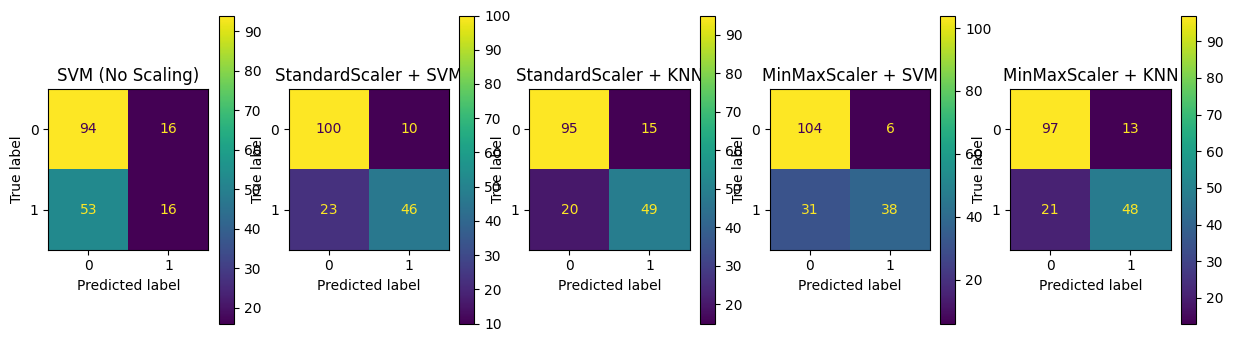

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(15, 4))

ConfusionMatrixDisplay.from_predictions(y_test, pred_svm_no_scaling, ax=axes[0])
axes[0].set_title("SVM (No Scaling)")

ConfusionMatrixDisplay.from_predictions(y_test, pred_svm_std, ax=axes[1])
axes[1].set_title("StandardScaler + SVM")

ConfusionMatrixDisplay.from_predictions(y_test, pred_knn_std, ax=axes[2])
axes[2].set_title("StandardScaler + KNN")

ConfusionMatrixDisplay.from_predictions(y_test, pred_svm_minmax, ax=axes[3])
axes[3].set_title("MinMaxScaler + SVM")

ConfusionMatrixDisplay.from_predictions(y_test, pred_knn_minmax, ax=axes[4])
axes[4].set_title("MinMaxScaler + KNN")

# plt.tight_layout()
plt.show()

## 13. Classification Report 확인
- Precision / Recall / F1-score를 클래스별로 확인합니다.
- 단순 점수보다 더 세밀한 해석이 가능합니다.


In [ ]:
print("[SVM - No Scaling]")
print(classification_report(
    y_test,
    pred_svm_no_scaling,
    target_names=["Not Survived", "Survived"]
))

print("\n[StandardScaler + SVM]")
print(classification_report(
    y_test,
    pred_svm_std,
    target_names=["Not Survived", "Survived"]
))

print("\n[StandardScaler + KNN]")
print(classification_report(
    y_test,
    pred_knn_std,
    target_names=["Not Survived", "Survived"]
))

[SVM - No Scaling]
              precision    recall  f1-score   support

Not Survived       0.64      0.85      0.73       110
    Survived       0.50      0.23      0.32        69

    accuracy                           0.61       179
   macro avg       0.57      0.54      0.52       179
weighted avg       0.59      0.61      0.57       179


[StandardScaler + SVM]
              precision    recall  f1-score   support

Not Survived       0.81      0.91      0.86       110
    Survived       0.82      0.67      0.74        69

    accuracy                           0.82       179
   macro avg       0.82      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179


[StandardScaler + KNN]
              precision    recall  f1-score   support

Not Survived       0.83      0.86      0.84       110
    Survived       0.77      0.71      0.74        69

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighte

## 15. KNN의 `k` 값에 따라 성능이 어떻게 달라지는지 확인
- `k=1 ~ 15` 범위 정도를 빠르게 비교해 보면
  KNN이 얼마나 민감한지 감을 잡을 수 있습니다.
- 이 역시 baseline 탐색 과정의 일부입니다.


In [ ]:
knn_scores = []

for k in range(1, 16):
    pipe = Pipeline([
        ("preprocessor", preprocessor_std),
        ("model", KNeighborsClassifier(n_neighbors=k))
    ])
    
    pipe.fit(X_train_filled, y_train)
    pred = pipe.predict(X_test_filled)
    
    knn_scores.append({
        "k": k,
        "accuracy": accuracy_score(y_test, pred),
        "f1_score": f1_score(y_test, pred)
    })

knn_scores_df = pd.DataFrame(knn_scores)
best_knn_row = knn_scores_df.sort_values(by="accuracy", ascending=False).iloc[0]
display(knn_scores_df)
print(best_knn_row)

,k,accuracy,f1_score
0,1,0.776536,0.710145
1,2,0.770950,0.630631
2,3,0.804469,0.736842
3,4,0.776536,0.666667
4,5,0.798883,0.723077
5,6,0.815642,0.722689
6,7,0.815642,0.744186
7,8,0.815642,0.736000
8,9,0.810056,0.738462
9,10,0.804469,0.715447


k           14.000000
accuracy     0.826816
f1_score     0.747967
Name: 13, dtype: float64


### KNN의 k 값에 대한 해석

기본 비교 실험에서는 baseline의 일관성을 위해 `k=3`을 사용하였다.  
추가 탐색 결과, `k=14`에서 가장 높은 Accuracy/F1-score를 보였다.  
이를 통해 KNN은 Titanic 데이터에서 `k` 값에 민감하며 하이퍼파라미터 선택이 성능에 직접적인 영향을 준다는 점을 확인할 수 있었다.

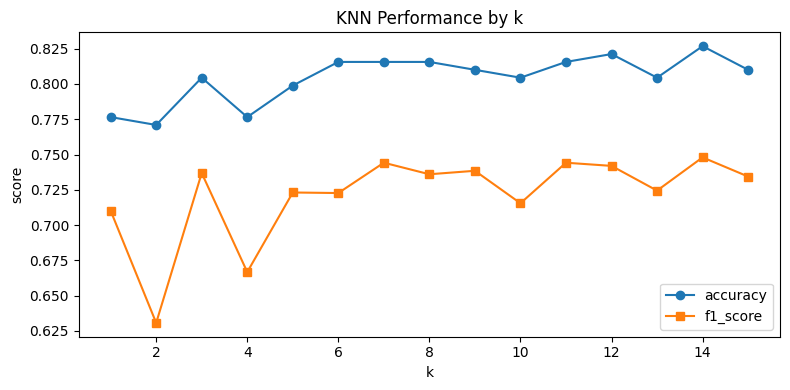

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(knn_scores_df["k"], knn_scores_df["accuracy"], marker="o", label="accuracy")
ax.plot(knn_scores_df["k"], knn_scores_df["f1_score"], marker="s", label="f1_score")
ax.set_title("KNN Performance by k")
ax.set_xlabel("k")
ax.set_ylabel("score")
ax.legend()
plt.tight_layout()
plt.show()


### 최종 정리

- `StandardScaler + SVM`이 `SVM (No Scaling)`보다 성능이 높기 때문에 SVM이 feature scale에 영향을 받는다는 점을 확인할 수 있다.
- KNN은 거리 기반 모델이므로 scaling 방식과 `k` 값에 특히 민감하다.
- `StandardScaler + KNN`과 `MinMaxScaler + KNN`을 비교하면 scaling 방식 차이도 확인할 수 있다.
- 본 실험에서는 StandardScaler + SVM 모델이 가장 높은 Accuracy를 보였고, MinMaxScaler + KNN 모델이 가장 높은 F1-score를 보였다. 따라서 Titanic 분류에서 어떤 모델이 더 적합한지는 평가 기준에 따라 달라질 수 있다. 전반적인 정확도 측면에서는 StandardScaler + SVM이 우수했고, 정밀도와 재현율의 균형 측면에서는 MinMaxScaler + KNN이 더 적합한 것으로 해석할 수 있다. 다만 두 모델의 F1-score 차이가 0.002462로 매우 작았기 때문에 전체적인 Accuracy는 `StandardScaler + SVM`이 더 높았으므로 본 과제에서는 `StandardScaler + SVM`을 Titanic 데이터셋에 가장 적합한 모델로 판단하였다.